# DATA

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gopalbhattrai/pascal-voc-2012-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset


# Code

In [32]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

In [33]:
class YOLO_v1(nn.Module):
    def __init__(self,split_size=7, num_boxes=2, num_classes=20,transform = None):
        super(YOLO_v1, self).__init__()
        self.num_classes = num_classes
        self.split_size = split_size
        self.transform = transform
        self.features = nn.Sequential(
            # --- KHỐI 1 ---
            # Output: (64, 224, 224)
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            # Output: (64, 112, 112)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # --- KHỐI 2 ---
            # Output: (192, 112, 112)
            nn.Conv2d(64, 192, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(192),
            nn.LeakyReLU(0.1),
            # Output: (192, 56, 56)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # --- KHỐI 3 (Lặp tuần tự các cặp 1x1 và 3x3) ---
            # Output: (128, 56, 56)
            nn.Conv2d(192, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),

            # Output: (256, 56, 56)
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),

            # Output: (256, 56, 56)
            nn.Conv2d(256, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),

            # Output: (512, 56, 56)
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Output: (512, 28, 28)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # --- KHỐI 4 (Cấu trúc lặp lại 4 lần cặp Conv 1x1 và 3x3) ---
            # Lần 1
            nn.Conv2d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Lần 2
            nn.Conv2d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Lần 3
            nn.Conv2d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Lần 4
            nn.Conv2d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Thêm 2 lớp Conv phụ trước khi Downsample
            # Output: (512, 28, 28)
            nn.Conv2d(512, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            # Output: (1024, 28, 28)
            nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Output: (1024, 14, 14)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # --- KHỐI 5 (Cấu trúc lặp lại 2 lần cặp Conv 1x1 và 3x3) ---
            # Lần 1
            nn.Conv2d(1024, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Lần 2
            nn.Conv2d(1024, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Các lớp Conv cuối cùng để hạ kích thước về đúng lưới mong muốn
            # Output: (1024, 14, 14)
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Ổn định kích thước hình học bằng Stride=2 ở Conv thay vì dùng MaxPool
            # Output: (1024, 7, 7)
            nn.Conv2d(1024, 1024, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Hai lớp Conv cuối cùng chuẩn bị cho tầng Fully Connected
            # Output: (1024, 7, 7)
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Output: (1024, 7, 7)
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * split_size * split_size,4096),
            nn.Dropout(0.5),
            nn.LeakyReLU(0.1),
            nn.Linear(4096,(split_size * split_size *  (num_classes + num_boxes * 5)))
        )


    def forward(self,X):
        feature = self.features(X)
        fc =self.fc(feature)
        return fc # Can reshape neu muon shape dang (split_size,split_size,C + B*2)

In [34]:
def calculate_IOU(predict,ground_truth): #Bao gom (B,S,S,4)
    min_predict_x = predict[...,0:1] - predict[...,2:3] / 2
    max_predict_x = predict[...,0:1] + predict[...,2:3] / 2
    min_predict_y = predict[...,1:2] - predict[...,3:4] / 2
    max_predict_y = predict[...,1:2] + predict[...,3:4] /2

    min_GT_x = ground_truth[...,0:1] - ground_truth[...,2:3] / 2
    max_GT_x = ground_truth[...,0:1] +  ground_truth[...,2:3] / 2
    min_GT_y  = ground_truth[...,1:2] - ground_truth[...,3:4] /2
    max_GT_y  = ground_truth[...,1:2] + ground_truth[...,3:4] /2

    Intersection_X = torch.min(max_predict_x,max_GT_x) - torch.max(min_predict_x,min_GT_x)
    Intersection_Y =  torch.min(max_predict_y,max_GT_y) - torch.max(min_predict_y,min_GT_y)

    Intersection = Intersection_X.clamp(0) * Intersection_Y.clamp(0)

    Union = predict[...,2:3] * predict[...,3:4] + ground_truth[...,2:3] * ground_truth[...,3:4] + 1e-6 - Intersection

    return Intersection / Union



In [35]:
class Loss_YOLO(nn.Module):
    def __init__(self,split_size,B,C,lambda_coor,lambda_noobj):
        super(Loss_YOLO,self).__init__()
        self.split_size = split_size
        self.B = B
        self.C = C
        self.lambda_coor = lambda_coor
        self.lambda_noobj = lambda_noobj
        self.loss = nn.MSELoss(reduction="sum") # Khong chia trung binh vi thay doi tham so mean -> sum
    def forward(self,predict,ground_truth): # Dang xet B = 2
        predict = predict.reshape(-1,self.split_size,self.split_size,self.C + self.B * 5)
        # list xywh
        exist_boxes = ground_truth[...,20].unsqueeze(3) # chi co hoac khong
        IOU_1 = calculate_IOU(predict[...,21:25],ground_truth[...,21:25])
        IOU_2 = calculate_IOU(predict[...,26:30],ground_truth[...,21:25])
        IOU = torch.cat([IOU_1.unsqueeze(0), IOU_2.unsqueeze(0)], dim=0) # Bị sai chỗ nàyyy !!! Đã sửa bằng gemini

        val_IOU,ind_IOU = torch.max(IOU,dim = 0) # Trong batch_size * 2 thi chi duoc lay 1 thang IOU cao nhat voi GT o o co dia chi do !!!
        # ind_IOU chi la 0 hoac 1

        best_BBox = ((1 - ind_IOU) * predict[...,21:25] + ind_IOU * predict[...,26:30]) * exist_boxes # Ben trong la lay thang IOU max sau do nhan voi exist_boxes de lua nhung o co object
        GT_BBox = ground_truth[...,21:25]  * exist_boxes # FOR MY SAFETY SIR =))) Nhân exist_boxes cho an toàn vì có thể dính số 0.

        mse_loss_xy = self.loss(
            torch.flatten(best_BBox[..., 0:2], end_dim=-2),
            torch.flatten(GT_BBox[..., 0:2], end_dim=-2)
        )

        best_BBox_wh_sqrt = torch.sqrt(torch.clamp(best_BBox[..., 2:4], min=1e-6))
        GT_BBox_wh_sqrt = torch.sqrt(torch.clamp(GT_BBox[..., 2:4], min=1e-6))

        mse_loss_wh = self.loss(
            torch.flatten(best_BBox_wh_sqrt, end_dim=-2),
            torch.flatten(GT_BBox_wh_sqrt, end_dim=-2)
        )

        mse_loss = mse_loss_xy + mse_loss_wh

        best_conf = ((1 - ind_IOU) * predict[...,20:21] + ind_IOU * predict[...,25:26])
        obj_loss = self.loss(torch.flatten(best_conf  * exist_boxes ),torch.flatten(ground_truth[...,20:21]  * exist_boxes))

        noobj_loss = self.loss(torch.flatten((1- exist_boxes) * predict[...,20:21]),torch.flatten((1- exist_boxes) *ground_truth[...,20:21]))
        noobj_loss += self.loss(torch.flatten((1- exist_boxes) * predict[...,25:26]),torch.flatten((1- exist_boxes) * ground_truth[...,20:21]))

        predict_probas = predict[...,:20]
        GT_probas = ground_truth[...,:20]

        probas_loss = self.loss(torch.flatten(predict_probas * exist_boxes,end_dim = -2),torch.flatten(GT_probas* exist_boxes,end_dim = -2) )

        loss = mse_loss * self.lambda_coor + obj_loss + self.lambda_noobj * noobj_loss +    probas_loss
        return loss

In [36]:
path

'/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset'

# PRINT XML FILE Function

In [38]:
import os
import torch
import xml.etree.ElementTree as ET
from PIL import Image
from torch.utils.data import Dataset
def print_xml_structure(element, level=0):
    # In tên thẻ kèm theo khoảng trống thụt lề tùy theo cấp độ (level)
    print("    " * level + f"|-- <{element.tag}>")
    
    # Đệ quy để in tiếp các thẻ con bên trong
    for child in element:
        print_xml_structure(child, level + 1)

In [39]:
tree = ET.parse("/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/Annotations/2007_000027.xml")
root = tree.getroot()
print_xml_structure(root)

|-- <annotation>
    |-- <folder>
    |-- <filename>
    |-- <source>
        |-- <database>
        |-- <annotation>
        |-- <image>
    |-- <size>
        |-- <width>
        |-- <height>
        |-- <depth>
    |-- <segmented>
    |-- <object>
        |-- <name>
        |-- <pose>
        |-- <truncated>
        |-- <difficult>
        |-- <bndbox>
            |-- <xmin>
            |-- <ymin>
            |-- <xmax>
            |-- <ymax>
        |-- <part>
            |-- <name>
            |-- <bndbox>
                |-- <xmin>
                |-- <ymin>
                |-- <xmax>
                |-- <ymax>
        |-- <part>
            |-- <name>
            |-- <bndbox>
                |-- <xmin>
                |-- <ymin>
                |-- <xmax>
                |-- <ymax>
        |-- <part>
            |-- <name>
            |-- <bndbox>
                |-- <xmin>
                |-- <ymin>
                |-- <xmax>
                |-- <ymax>
        |-- <part>
      

# Dataset and DataLoader

## Lỗi sai trong Phần DataSet ở dưới(đã fix) !
> https://gemini.google.com/share/dbd54c00b726


In [22]:
mapp = {
            "aeroplane": 0, "bicycle": 1, "bird": 2, "boat": 3, "bottle": 4,
            "bus": 5, "car": 6, "cat": 7, "chair": 8, "cow": 9, "diningtable": 10,
            "dog": 11, "horse": 12, "motorbike": 13, "person": 14, "pottedplant": 15,
            "sheep": 16, "sofa": 17, "train": 18, "tvmonitor": 19
        }

for obj in root.findall('object'):
    main_name = obj.find('name').text
    print(mapp[main_name])

14


In [23]:
class PascalVOCDataset(Dataset):
    def __init__(self, xml_dir, img_dir, S=7, B=2, C=20, transform=None):
        self.xml_dir = xml_dir
        self.img_dir = img_dir
        self.S = S
        self.B = B
        self.C = C
        self.transform = transform
        # Tách tên file và đuôi file ra, chỉ lấy phần tên [0]
        self.filenames = [os.path.splitext(f)[0] for f in os.listdir(xml_dir) if f.endswith('.xml')]

        # Bảng ánh xạ 20 class chuẩn của Pascal VOC thành dạng số (0 -> 19)
        self.classes_mapping = {
            "aeroplane": 0, "bicycle": 1, "bird": 2, "boat": 3, "bottle": 4,
            "bus": 5, "car": 6, "cat": 7, "chair": 8, "cow": 9, "diningtable": 10,
            "dog": 11, "horse": 12, "motorbike": 13, "person": 14, "pottedplant": 15,
            "sheep": 16, "sofa": 17, "train": 18, "tvmonitor": 19
        }

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, index):
        img_path = os.path.join(self.img_dir, self.filenames[index] + ".jpg")
        image = Image.open(img_path).convert("RGB")

        xml_path = os.path.join(self.xml_dir,self.filenames[index] + ".xml")
        tree = ET.parse(xml_path)
        root = tree.getroot()

        width = float(root.find('size').find('width').text)
        height = float(root.find('size').find('height').text)

        check_tensor = torch.zeros(self.S,self.S,self.B * 5 + self.C)
        
        for obj in root.findall('object'):
            name = obj.find('name').text
            if name not in self.classes_mapping:
                continue
            class_idx = self.classes_mapping[name]
            
            bbox  = obj.find('bndbox')
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            
            x = (xmin + xmax) / (2.0 * width)
            y = (ymax + ymin) / (2.0 * height)
            w = (xmax - xmin) / width
            h = (ymax - ymin) / height

            num_blocks_x = int(x * self.S)
            num_blocks_y = int(y * self.S)
            
            if check_tensor[num_blocks_y,num_blocks_x,20] == 0:
                # Ca hai deu bi fix trong range(0,1)
                coor_x_in_cell = x * self.S - num_blocks_x
                coor_y_in_cell = y * self.S - num_blocks_y
                
                check_tensor[num_blocks_y,num_blocks_x,21:25] = torch.tensor([coor_x_in_cell,coor_y_in_cell,w,h])

                check_tensor[num_blocks_y,num_blocks_x,20] = 1
                check_tensor[num_blocks_y,num_blocks_x,class_idx] = 1

        # Áp dụng các phép biến đổi Augmentation/Resize (nếu có)
        if self.transform:
            image = self.transform(image)

        return image, check_tensor

In [24]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

def train_fn(train_loader, model, optimizer, criterion, DEVICE):
    model.train()
    total_epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        outputs = model(images)

        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"Batch [{batch_idx + 1}/{len(train_loader)}] | Batch Loss: {loss.item():.4f}")

    print(f"==> Toàn bộ Epoch Loss: {total_epoch_loss / len(train_loader):.4f}")
    return total_epoch_loss / len(train_loader)

def val_fn(val_loader,model,criterion,DEVICE):
    model.eval()
    total_epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(val_loader):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        outputs = model(images)

        loss = criterion(outputs, targets)
        total_epoch_loss += loss.item()
    return total_epoch_loss / len(val_loader)




DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 5

transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
])

XML_TRAINVAL_DIR = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/Annotations"
IMG_TRAINVAL_DIR = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages"

XML_TEST_DIR = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test/Annotations"
IMG_TEST_DIR = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test/JPEGImages"




In [26]:
import torch
from torch.utils.data import random_split

 
train_val_dataset = PascalVOCDataset(xml_dir=XML_TRAINVAL_DIR, img_dir=IMG_TRAINVAL_DIR, transform=transform)
test_dataset = PascalVOCDataset(xml_dir = XML_TEST_DIR,img_dir = IMG_TEST_DIR,transform = transform)

train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size

train_dataset,val_dataset = random_split(train_val_dataset,[train_size,val_size])
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    drop_last=True
)
val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 4,
    drop_last = True
)
test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 4,
    drop_last = False
)

In [ ]:
print(len(train_loader))
len(val_loader)

In [27]:
# Lấy 1 batch từ val_loader
images, targets = next(iter(train_loader))
for y in range(7):
    for x in range(7):
        if targets[0, y, x, 20] == 1:
            print(f"--- Tìm thấy vật thể ở ô lưới [Hàng {y}, Cột {x}] ---")
            print("Vector 30 phần tử của ô này:")
            print(targets[0, y, x])
            break

--- Tìm thấy vật thể ở ô lưới [Hàng 3, Cột 5] ---
Vector 30 phần tử của ô này:
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 1.0000, 0.3830, 0.1920, 0.2260, 0.5173, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000])


In [28]:
import torch.optim as optim
model = YOLO_v1(7,2,20,transform)
model.to(DEVICE)
optimizer = optim.AdamW(model.parameters(),lr = LEARNING_RATE)
criterion = Loss_YOLO(7,2,20,5,0.5)

In [41]:
def train(MODEL_FILE):
    best_val_loss = torch.inf
    model.train()
    train_loss_his = []
    val_loss_his = []
    for epoch in range(EPOCHS):
        avg_train_loss = train_fn(train_loader,model,optimizer,criterion,DEVICE)
        avg_val_loss = val_fn(val_loader,model,criterion,DEVICE)
        print(f"EPOCH: {epoch + 1}: Train Loss: {avg_train_loss} ---- Val Loss: {avg_val_loss}")
        train_loss_his.append(avg_train_loss)
        val_loss_his.append(avg_val_loss)
        if(best_val_loss > avg_val_loss):
            best_val_loss = avg_val_loss
            print("Best model is saved !!!")
            torch.save(model.state_dict(),MODEL_FILE)

    return train_loss_his,val_loss_his

            

# Inference_function

In [59]:
def inference(iou_threshold = 0.5,score_threshold = 0.4):
    my_yolo = YOLO_v1(7,2,20,transform)
    checkpoint = torch.load('model.pth', map_location=DEVICE)
    my_yolo.to(DEVICE)
    my_yolo.load_state_dict(checkpoint)
    my_yolo.eval()
    with torch.no_grad():
        predict_lists = []
        GT_lists = []
        count = 0
        for iters,(inputs,targets) in enumerate(test_loader):
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            flatten_targets = targets.contiguous().view(-1,targets.shape[1] * targets.shape[2],targets.shape[3])
    
            
            
            targets_idx = torch.argmax(targets[...,:20],dim = -1)
            flatten_targets_idx = targets_idx.contiguous().view(-1,targets_idx.shape[1] * targets_idx.shape[2])
            
            outputs = my_yolo(inputs) # batchx7x7x30 vi B = 2
            
            probas = outputs[...,:20]
            bbox_1 = outputs[...,21:25]
            bbox_2 = outputs[...,26:30]
            conf_1 = outputs[...,20:21]
            conf_2 = outputs[...,25:26]
            # Prepare for algorithm
            # Lưu ý đoạn này !!!!
            bbox = torch.stack([bbox_1, bbox_2], dim=-2) #(b,7,7,2,4)
            conf = torch.stack([conf_1, conf_2], dim=-2).squeeze(-1) #(b,7,7,2)
            
            flatted_bbox = bbox.contiguous().view(bbox.shape[0], -1, 4)  # (batch, 98, 4)
            flatted_conf = conf.contiguous().view(conf.shape[0], -1)
    
            max_probas,max_probas_idx = torch.max(probas,dim = -1) #(b,7,7)
            max_probas = torch.stack([max_probas,max_probas],dim = -2) # (b,7,7,2)
            max_probas_idx = torch.stack([max_probas_idx,max_probas_idx],dim = -2)
    
            max_probas = max_probas.contiguous().view(flatted_conf.shape)
            max_probas_idx = max_probas_idx.contiguous().view(flatted_conf.shape)
            scores = max_probas * flatted_conf # (b,98) 98 cai bbox nhe
            
            
            
            indices = torch.argsort(scores,dim = 1,descending = True)
            bbox_indices = indices.unsqueeze(-1).expand(-1,-1,4)
    
            sorted_bbox = torch.gather(flatted_bbox,dim = 1,index = bbox_indices)
            sorted_conf = torch.gather(flatted_conf,dim = 1,index = indices)
            sorted_class_id = torch.gather(max_probas_idx,dim = 1,index = indices)
            sorted_scores = torch.gather(scores,dim = 1,index = indices)
    
            
            visited = torch.zeros_like(sorted_conf,dtype=torch.bool)
            for b in range(sorted_conf.shape[0]): 
                for i in range(sorted_conf.shape[1]): # 98 iteration
                    # Add GT_bbox
                    if(i % 2 == 0 and flatten_targets[b,(i//2),20] > 0):
                        GT_lists.append({
                        "bbox" : flatten_targets[b,(i//2),21:25],
                        "class_id" : flatten_targets_idx[b,(i//2)],
                        "index_batch" : count
                        })
                    # Add predict_bbox
                    if sorted_scores[b, i] < score_threshold:
                            break
                    if visited[b,i]:
                        continue
                    predict_lists.append({
                            "bbox": sorted_bbox[b, i],
                            "class_id": sorted_class_id[b, i].item(),
                            "score": sorted_scores[b, i].item(),
                            "index_batch" : count
                        })
                    visited[b,i] = 1
                    
                    remaining_indices = torch.where(~visited[b,i+1:])[0] + i + 1 # Good technique
    
                    if(len(remaining_indices) == 0): continue
    
                    iou_scores = calculate_IOU(predict_lists[-1]["bbox"],sorted_bbox[b,remaining_indices]).squeeze()
                    masks = sorted_class_id[b,remaining_indices] == predict_lists[-1]["class_id"]
                    discard_idx = remaining_indices[(iou_scores > iou_threshold) & masks]
                    visited[b,discard_idx] = True
                count += 1
         #(-1,bbox)
        #(-1,bbox)
        return predict_lists,GT_lists,count

In [61]:
def mAP(model = model,device = DEVICE,iou_threshold = 0.5): 
    predict_lists,GT_lists = inference(iou_threshold = iou_threshold)
    AP = []
    
    for category in range(model.num_classes):
        pred_category = [obj for obj in predict_lists if obj["class_id"] == category ]
        # Sort theo confident score
        pred_category.sort(key=lambda x: x["score"], reverse=True)
        GT_category = [obj for obj in GT_lists if obj["class_id"] == category ]

        TP = torch.zeros((len(pred_category)))
        FP = torch.zeros((len(pred_category)))
        num_GT_bboxes = len(GT_category)

        # Tao ra check GT bbox nay da duoc check chua
        gt_seen = {}
        for gt_obj in GT_category:
            b_idx = gt_obj["index_batch"]
            if b_idx not in gt_seen:
                # Đếm xem batch này có bao nhiêu GT thuộc class hiện tại
                num_gt_in_batch = sum(1 for x in GT_category if x["index_batch"] == b_idx)
                gt_seen[b_idx] = torch.zeros(num_gt_in_batch, dtype=torch.bool)
        
        for count_idx,bbox in enumerate(pred_category):
            GT_same_idx = [(idx,obj) for idx,obj in enumerate(GT_category) if obj["index_batch"] == bbox["index_batch"]]
            
            best_IOU = 0
            best_gt_idx = -1
            for GT_bbox in GT_same_idx:
                IOU = calculate_IOU(bbox,GT_bbox[1])
                if IOU > best_IOU:
                    best_IOU = IOU
                    best_gt_idx = GT_bbox[0]
                    
            if(best_IOU > iou_threshold):
                local_gt_idx = sum(1 for x in GT_category[:best_gt_idx] if x["index_batch"] == bbox['index_batch'])
                
                if gt_seen[bbox['index_batch']][local_gt_idx] == False:
                    TP[count_idx] = 1
                    gt_seen[bbox['index_batch']][local_gt_idx] = True
                else:
                    FP[count_idx] = 1
            else:
                FP[count_idx] = 1

        TP_cumsum = torch.cumsum(TP, dim=0)
        FP_cumsum = torch.cumsum(FP, dim=0)
        Recall = TP_cumsum / (1e-6 + num_GT_bboxes)
        Precision = torch.divide(TP_cumsum, (TP_cumsum + FP_cumsum + 1e-6))
        Recall = torch.cat(torch.tensor([0]), Recall)
        Precision = torch.cat(torch.tensor([1]),Precision)
        AP.append(torch.trapzoid(Precision, Recall))
    return sum(AP) / len(AP)


        
                    
                

            

    
        
        
        
    
    
        

In [42]:
MODEL_FILE = "model.pth"
train_loss,val_loss = train(MODEL_FILE)

Batch [100/856] | Batch Loss: 163.1995
Batch [200/856] | Batch Loss: 115.8024
Batch [300/856] | Batch Loss: 175.1846
Batch [400/856] | Batch Loss: 96.7119
Batch [500/856] | Batch Loss: 137.4693
Batch [600/856] | Batch Loss: 118.4042
Batch [700/856] | Batch Loss: 99.9661
Batch [800/856] | Batch Loss: 97.3354
==> Toàn bộ Epoch Loss: 119.5364
EPOCH: 1: Train Loss: 119.53635585642307 ---- Val Loss: 97.5086596123526
Best model is saved !!!
Batch [100/856] | Batch Loss: 126.5533
Batch [200/856] | Batch Loss: 66.1092
Batch [300/856] | Batch Loss: 106.0245
Batch [400/856] | Batch Loss: 115.2726
Batch [500/856] | Batch Loss: 106.0420
Batch [600/856] | Batch Loss: 102.6144
Batch [700/856] | Batch Loss: 98.2171
Batch [800/856] | Batch Loss: 73.3903
==> Toàn bộ Epoch Loss: 98.0707
EPOCH: 2: Train Loss: 98.07072173323587 ---- Val Loss: 101.02766528976298
Batch [100/856] | Batch Loss: 86.8402
Batch [200/856] | Batch Loss: 97.8540
Batch [300/856] | Batch Loss: 96.3061
Batch [400/856] | Batch Loss: 91

# Plot Train,Validation Loss

In [46]:
a = torch.rand(2,3,4)
b = torch.rand(3,1,8)
print(b.contiguous().view(a.shape))

tensor([[[0.9984, 0.5568, 0.6065, 0.9140],
         [0.6122, 0.8662, 0.3602, 0.9460],
         [0.2819, 0.9753, 0.1705, 0.2571]],

        [[0.9221, 0.3653, 0.4973, 0.7437],
         [0.4956, 0.5055, 0.3109, 0.0335],
         [0.7732, 0.6686, 0.1634, 0.2039]]])


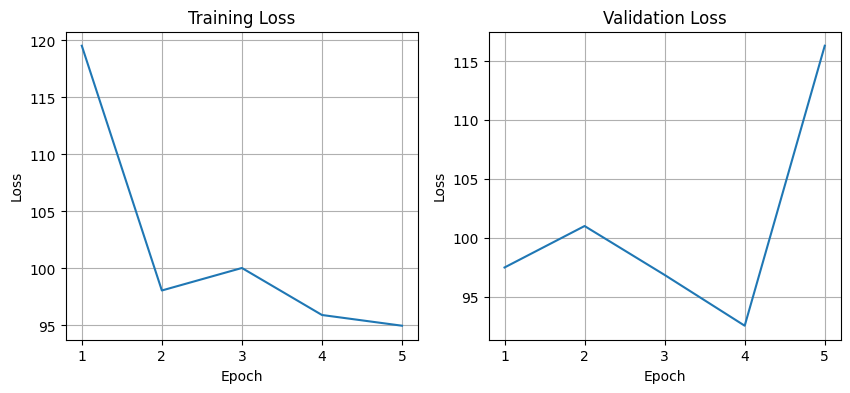

In [47]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_loss(train_loss,val_loss):
    epoch = torch.arange(1,len(train_loss) + 1)
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].set_title("Training Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].plot(epoch,train_loss)
    axs[0].grid(True)

    axs[1].set_title("Validation Loss")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Loss")
    axs[1].plot(epoch,val_loss)
    axs[1].grid(True)
    plt.show()    
plot_loss(train_loss,val_loss)


In [62]:
mAP()

ValueError: too many values to unpack (expected 2)